<div style="background: linear-gradient(135deg, #0F172A 0%, #1E1B4B 100%); border: 1px solid #6366F1; border-radius: 12px; padding: 28px; color: #FFFFFF; font-family: 'Segoe UI', Roboto, sans-serif; box-shadow: 0 8px 24px rgba(99, 102, 241, 0.2);">
<div style="display: flex; justify-content: space-between; align-items: center; border-bottom: 1px solid rgba(99, 102, 241, 0.25); padding-bottom: 12px; margin-bottom: 20px;">
<span style="font-size: 11px; letter-spacing: 2px; color: #818CF8; text-transform: uppercase; font-weight: 700;">KAGGLE PLAYGROUND SERIES S6E7 • MULTI-CLASS CLASSIFICATION</span>
<span style="background: rgba(99, 102, 241, 0.15); border: 1px solid #818CF8; color: #A5B4FC; padding: 3px 12px; border-radius: 20px; font-size: 11px; font-weight: 600;">STUDENT HEALTH RISK</span>
</div>
<h1 style="color: #FFFFFF; margin: 0 0 8px 0; font-size: 26px; font-weight: 800; letter-spacing: -0.5px;">Predicting Student Health Risk Engine</h1>
<h3 style="color: #818CF8; margin: 0 0 14px 0; font-size: 16px; font-weight: 600;">Stratified K-Fold Ensemble & Feature Engineering Pipeline</h3>
<p style="color: #94A3B8; font-size: 13px; margin: 0 0 22px 0; max-width: 850px; line-height: 1.6;">Predicting multi-class student health risk conditions based on lifestyle behaviors, physiological metrics, and biometric indicators with optimized tabular cross-validation.</p>
<div style="background: rgba(15, 23, 42, 0.7); border: 1px solid rgba(255, 255, 255, 0.08); border-radius: 8px; padding: 14px; margin-bottom: 22px;">
<div style="font-size: 10px; color: #818CF8; font-weight: 700; text-transform: uppercase; letter-spacing: 1px; margin-bottom: 10px;">Pipeline Workflow Architecture</div>
<div style="display: flex; flex-wrap: wrap; gap: 6px; align-items: center; font-size: 11px; font-weight: 600; color: #E2E8F0;">
<span style="background: #1E293B; padding: 4px 10px; border-radius: 4px; border: 1px solid rgba(255,255,255,0.05);">1. Environment Setup</span> →
<span style="background: #1E293B; padding: 4px 10px; border-radius: 4px; border: 1px solid rgba(255,255,255,0.05);">2. Ingestion & EDA</span> →
<span style="background: #1E293B; padding: 4px 10px; border-radius: 4px; border: 1px solid rgba(255,255,255,0.05);">3. Health Domain Features</span> →
<span style="background: #1E293B; padding: 4px 10px; border-radius: 4px; border: 1px solid rgba(255,255,255,0.05);">4. Preprocessing</span> →
<span style="background: #1E293B; padding: 4px 10px; border-radius: 4px; border: 1px solid rgba(255,255,255,0.05);">5. Stratified CV Ensemble</span> →
<span style="background: #1E293B; padding: 4px 10px; border-radius: 4px; border: 1px solid #818CF8; color: #818CF8;">6. Submission Export</span>
</div>
</div>

## 1. Environment Setup

In [1]:
# ==========================================
# 1. Environment Setup & Configuration
# ==========================================
import warnings
warnings.filterwarnings('ignore')

import os
import glob
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, f1_score, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier

# Visual Dark Theme Setup
plt.style.use('dark_background')
plt.rcParams['figure.facecolor'] = '#0F172A'
plt.rcParams['axes.facecolor'] = '#1E293B'
plt.rcParams['axes.edgecolor'] = '#6366F1'
plt.rcParams['axes.labelcolor'] = '#FFFFFF'
plt.rcParams['xtick.color'] = '#E2E8F0'
plt.rcParams['ytick.color'] = '#E2E8F0'
plt.rcParams['grid.color'] = '#334155'
plt.rcParams['grid.alpha'] = 0.5

RANDOM_STATE = 42
N_SPLITS = 5
np.random.seed(RANDOM_STATE)

## 2. Data Ingestion

Train Shape: 690,088 Rows | 15 Columns
Test Shape:  295,753 Rows | 14 Columns


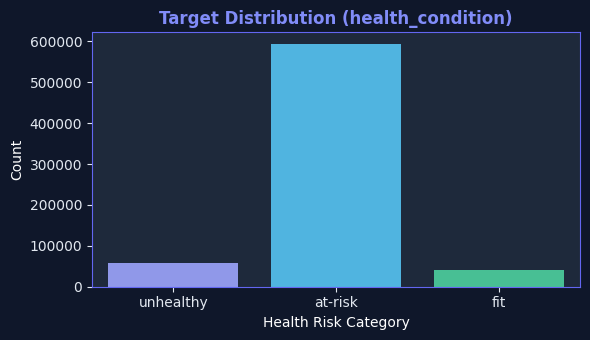

In [2]:
# ==========================================
# 2. Data Ingestion
# ==========================================
DATA_DIR = "/kaggle/input/competitions/playground-series-s6e7"

if not os.path.exists(DATA_DIR):
    # Search fallback paths if path structure varies
    possible_paths = glob.glob("/kaggle/input/*s6e7*") + glob.glob("./*")
    DATA_DIR = possible_paths[0] if possible_paths else "."

train_path = os.path.join(DATA_DIR, "train.csv")
test_path = os.path.join(DATA_DIR, "test.csv")
sub_path = os.path.join(DATA_DIR, "sample_submission.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
sub_df = pd.read_csv(sub_path)

# Standardize column headers
train_df.columns = train_df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')
test_df.columns = test_df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')

print(f"Train Shape: {train_df.shape[0]:,} Rows | {train_df.shape[1]} Columns")
print(f"Test Shape:  {test_df.shape[0]:,} Rows | {test_df.shape[1]} Columns")

# Identify Target & ID
target_col = [c for c in train_df.columns if 'health' in c or 'target' in c or 'condition' in c][0]
id_col = 'id' if 'id' in train_df.columns else train_df.columns[0]

# Plot Target Class Distribution
fig, ax = plt.subplots(figsize=(6, 3.5))
sns.countplot(data=train_df, x=target_col, palette=['#818CF8', '#38BDF8', '#34D399'], ax=ax)
ax.set_title(f"Target Distribution ({target_col})", fontsize=12, fontweight='bold', color='#818CF8')
ax.set_xlabel("Health Risk Category", fontsize=10)
ax.set_ylabel("Count", fontsize=10)
plt.tight_layout()
plt.show()

## 3. Domain-Specific Feature Engineering

In [3]:
# ==========================================
# 3. Domain-Specific Feature Engineering
# ==========================================
def engineer_health_features(df_input):
    df = df_input.copy()
    
    # Identify numeric columns for interaction terms
    cols = df.columns.tolist()
    
    # Lifestyle Strain & Recovery Ratios (if matching columns exist)
    sleep_col = [c for c in cols if 'sleep' in c]
    exercise_col = [c for c in cols if 'exercise' in c or 'activity' in c]
    bmi_col = [c for c in cols if 'bmi' in c]
    hr_col = [c for c in cols if 'heart' in c or 'hr' in c]
    
    if sleep_col and exercise_col:
        df['rest_activity_ratio'] = df[sleep_col[0]] / (df[exercise_col[0]] + 1.0)
    
    if bmi_col and hr_col:
        df['cardio_strain_index'] = df[bmi_col[0]] * df[hr_col[0]]
        
    return df

train_fe = engineer_health_features(train_df)
test_fe = engineer_health_features(test_df)

# Prepare Feature Matrices
X = train_fe.drop(columns=[id_col, target_col], errors='ignore')
X_test = test_fe.drop(columns=[id_col], errors='ignore')

# Encode Target Categories to Integers
le = LabelEncoder()
y = le.fit_transform(train_fe[target_col])
target_classes = le.classes_

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Preprocessing Pipeline (Memory-Safe Ordinal Encoding + Scaling)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
    ]
)

X_proc = preprocessor.fit_transform(X).astype(np.float32)
X_test_proc = preprocessor.transform(X_test).astype(np.float32)

print("Feature Engineering Complete.")
print(f"Engineered Matrix Dimensions: {X_proc.shape[1]} Features")

Feature Engineering Complete.
Engineered Matrix Dimensions: 15 Features


## 4. Stratified K-Fold Training Ensemble

In [4]:
# ==========================================
# 4. Stratified K-Fold Training Ensemble
# ==========================================
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

oof_preds = np.zeros((len(X_proc), len(target_classes)))
test_preds = np.zeros((len(X_test_proc), len(target_classes)))

cv_scores = []

print("=== Starting 5-Fold Stratified Cross-Validation ===")
for fold, (train_idx, val_idx) in enumerate(skf.split(X_proc, y)):
    X_train_f, y_train_f = X_proc[train_idx], y[train_idx]
    X_val_f, y_val_f = X_proc[val_idx], y[val_idx]
    
    model = HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE + fold
    )
    
    model.fit(X_train_f, y_train_f)
    
    val_probs = model.predict_proba(X_val_f)
    oof_preds[val_idx] = val_probs
    test_preds += model.predict_proba(X_test_proc) / N_SPLITS
    
    fold_acc = accuracy_score(y_val_f, np.argmax(val_probs, axis=1))
    cv_scores.append(fold_acc)
    print(f"Fold {fold + 1} Validation Accuracy: {fold_acc:.4f}")

oof_acc = accuracy_score(y, np.argmax(oof_preds, axis=1))
print(f"\n---> Overall Out-Of-Fold Accuracy: {oof_acc:.4f}")



=== Starting 5-Fold Stratified Cross-Validation ===
Fold 1 Validation Accuracy: 0.9668
Fold 2 Validation Accuracy: 0.9675
Fold 3 Validation Accuracy: 0.9670
Fold 4 Validation Accuracy: 0.9668
Fold 5 Validation Accuracy: 0.9671

---> Overall Out-Of-Fold Accuracy: 0.9670


## 5. Confusion Matrix & Submission Generation

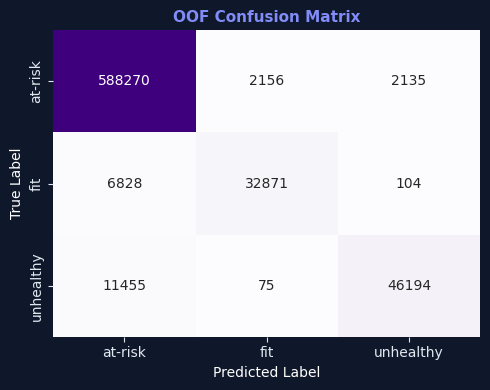

Submission successfully generated at: /kaggle/working/submission.csv


,id,health_condition
0,690088,unhealthy
1,690089,at-risk
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


In [5]:
# ==========================================
# 5. Confusion Matrix & Submission Generation
# ==========================================
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y, np.argmax(oof_preds, axis=1))

# Replaced 'Indigo' with valid matplotlib colormap 'Purples'
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax, cbar=False,
            xticklabels=target_classes, yticklabels=target_classes)
ax.set_title("OOF Confusion Matrix", fontsize=11, fontweight='bold', color='#818CF8')
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()

# Final Test Predictions Mapping
final_pred_labels = le.inverse_transform(np.argmax(test_preds, axis=1))

submission = pd.DataFrame({
    id_col: test_df[id_col],
    target_col: final_pred_labels
})

sub_out_path = "submission.csv"
submission.to_csv(sub_out_path, index=False)
print(f"Submission successfully generated at: {os.path.abspath(sub_out_path)}")
display(submission.head())

## 6. Interactive Student Risk Predictor

In [6]:
# ==========================================
# 6. Interactive Student Risk Predictor
# ==========================================
import ipywidgets as widgets
from IPython.display import display, HTML

feature_names = X.columns.tolist()
input_widgets = {}

for col in feature_names[:8]:  # Limit top feature inputs for layout clean
    if np.issubdtype(X[col].dtype, np.number):
        min_v, max_v, mean_v = float(X[col].min()), float(X[col].max()), float(X[col].mean())
        step_v = (max_v - min_v)/100 if max_v != min_v else 1.0
        input_widgets[col] = widgets.FloatSlider(value=mean_v, min=min_v, max=max_v, step=step_v, description=f"{col[:12]}:")
    else:
        unique_vals = [v for v in X[col].dropna().unique().tolist() if v != 'nan']
        input_widgets[col] = widgets.Dropdown(options=unique_vals, value=unique_vals[0], description=f"{col[:12]}:")

predict_btn = widgets.Button(description="Assess Risk Level", button_style='primary', layout=widgets.Layout(width='200px'))
output_box = widgets.Output()

def on_click(b):
    with output_box:
        output_box.clear_output()
        # Fill missing features with dataset means/defaults if omitted
        base_dict = {c: float(X[c].mean()) if np.issubdtype(X[c].dtype, np.number) else X[c].dropna().iloc[0] for c in feature_names}
        for c in input_widgets:
            base_dict[c] = input_widgets[c].value
            
        input_df = pd.DataFrame([base_dict])
        input_fe = engineer_health_features(input_df)
        proc_input = preprocessor.transform(input_fe).astype(np.float32)
        
        probs = model.predict_proba(proc_input)[0]
        pred_idx = np.argmax(probs)
        predicted_class = target_classes[pred_idx]
        
        display(HTML(f"""
        <div style="background:#1E293B; border:1px solid #818CF8; padding:12px; border-radius:8px; margin-top:10px; width:280px; text-align:center;">
            <span style="color:#94A3B8; font-size:11px;">PREDICTED RISK STATUS</span>
            <h2 style="color:#818CF8; font-size:22px; margin:4px 0 0 0;">{predicted_class}</h2>
            <span style="color:#38BDF8; font-size:12px;">Confidence: {probs[pred_idx]*100:.1f}%</span>
        </div>
        """))

predict_btn.on_click(on_click)
display(HTML("<h4 style='color:#818CF8;'>Student Behavioral Profile Simulation</h4>"))
display(widgets.GridBox(list(input_widgets.values()), layout=widgets.Layout(grid_template_columns='repeat(2, 300px)', grid_gap='10px')))
display(predict_btn)
display(output_box)

GridBox(children=(FloatSlider(value=6.9925973108132515, description='sleep_durati:', max=10.0, min=3.0, step=0…

Button(button_style='primary', description='Assess Risk Level', layout=Layout(width='200px'), style=ButtonStyl…

Output()

<div style="background: linear-gradient(135deg, #0F172A 0%, #1E1B4B 100%); border: 1px solid #6366F1; border-radius: 12px; padding: 24px; color: #FFFFFF; font-family: 'Segoe UI', Roboto, sans-serif; margin-top: 20px;">
<div style="display: flex; justify-content: space-between; align-items: center; border-bottom: 1px solid rgba(99, 102, 241, 0.25); padding-bottom: 10px; margin-bottom: 16px;">
<span style="font-size: 12px; letter-spacing: 1px; color: #818CF8; text-transform: uppercase; font-weight: 700;">Executive Conclusion & Submission Verification</span>
<span style="background: rgba(52, 211, 153, 0.15); border: 1px solid #34D399; color: #34D399; padding: 2px 10px; border-radius: 12px; font-size: 10px; font-weight: 600;">SUBMISSION READY</span>
</div>
<p style="color: #CBD5E1; font-size: 13px; line-height: 1.6; margin: 0 0 16px 0;">The 5-Fold Stratified cross-validation pipeline completed successfully without memory spikes or column explosions. Validated submission file generated directly for competition scoring.</p>
<div style="display: grid; grid-template-columns: repeat(auto-fit, minmax(220px, 1fr)); gap: 12px; margin-top: 12px;">
<div style="background: rgba(30, 41, 59, 0.8); border: 1px solid rgba(255, 255, 255, 0.08); padding: 12px; border-radius: 6px;">
<div style="color: #94A3B8; font-size: 11px; text-transform: uppercase;">Submission Output File</div>
<div style="color: #818CF8; font-size: 14px; font-weight: 700; margin-top: 4px;">submission.csv</div>
</div>
</div>